In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels openpyxl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor


In [10]:

df=pd.read_excel("cderberf.xlsx")

In [11]:
df.head()

,32298,CA-2012-124891,2012-07-31 00:00:00,2012-07-31 00:00:00.1,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,7,0,762.1844999999998,933.57,Critical,0.3299999999999999,0.1,0%,Profit,2012-07
0,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,9,0.1,-288.765,923.63,Critical,-0.077847,2,0-10%,Loss,2013-02
1,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,9,0.1,919.971,915.49,Medium,0.177766,1,0-10%,Profit,2013-10
2,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,5,0.1,-96.540,910.16,Medium,-0.033376,2,0-10%,Loss,2013-01
3,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,8,0.0,311.520,903.04,Critical,0.109963,1,0%,Profit,2013-11
4,22732,IN-2013-42360,2013-06-28,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,5,0.1,763.275,897.35,Critical,0.266630,3,0-10%,Profit,2013-06


In [12]:
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 29 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   32298                                                               51289 non-null  int64         
 1   CA-2012-124891                                                      51289 non-null  object        
 2   2012-07-31 00:00:00                                                 51289 non-null  datetime64[ns]
 3   2012-07-31 00:00:00.1                                               51289 non-null  datetime64[ns]
 4   Same Day                                                            51289 non-null  object        
 5   RH-19495                                                            51289 non-null  object        
 6   Rick Hansen                                           

In [14]:
df.columns = [str(c).strip().replace(" ", "_") for c in df.columns]
df.columns


Index(['32298', 'CA-2012-124891', '2012-07-31_00:00:00',
       '2012-07-31_00:00:00.1', 'Same_Day', 'RH-19495', 'Rick_Hansen',
       'Consumer', 'New_York_City', 'New_York', 'United_States', '10024', 'US',
       'East', 'TEC-AC-10003033', 'Technology', 'Accessories',
       'Plantronics_CS510_-_Over-the-Head_monaural_Wireless_Headset_System',
       '2309.65', '7', '0', '762.1844999999998', '933.57', 'Critical',
       '0.3299999999999999', '0.1', '0%', 'Profit', '2012-07'],
      dtype='object')

In [15]:
df.columns.tolist()


['32298',
 'CA-2012-124891',
 '2012-07-31_00:00:00',
 '2012-07-31_00:00:00.1',
 'Same_Day',
 'RH-19495',
 'Rick_Hansen',
 'Consumer',
 'New_York_City',
 'New_York',
 'United_States',
 '10024',
 'US',
 'East',
 'TEC-AC-10003033',
 'Technology',
 'Accessories',
 'Plantronics_CS510_-_Over-the-Head_monaural_Wireless_Headset_System',
 '2309.65',
 '7',
 '0',
 '762.1844999999998',
 '933.57',
 'Critical',
 '0.3299999999999999',
 '0.1',
 '0%',
 'Profit',
 '2012-07']

In [19]:
file_path = r"C:\Users\rpere\Downloads\ffffffffff.xlsx"

df = pd.read_excel(file_path, header=0)

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Quantity,Discount,Profit,Shipping Cost,Order Priority,Profit Margin,Shipping Days,Discount Band,Loss Flag,Year-Month
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,7,0.0,762.1845,933.57,Critical,0.330000,0,0%,Profit,2012-07
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,9,0.1,-288.7650,923.63,Critical,-0.077847,2,0-10%,Loss,2013-02
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,9,0.1,919.9710,915.49,Medium,0.177766,1,0-10%,Profit,2013-10
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,5,0.1,-96.5400,910.16,Medium,-0.033376,2,0-10%,Loss,2013-01
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,8,0.0,311.5200,903.04,Critical,0.109963,1,0%,Profit,2013-11


In [21]:
df = pd.read_excel(file_path, header=0)
df.columns.tolist()


['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'City',
 'State',
 'Country',
 'Postal Code',
 'Market',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping Cost',
 'Order Priority',
 'Profit Margin',
 'Shipping Days',
 'Discount Band',
 'Loss Flag',
 'Year-Month']

In [23]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")
df.columns.tolist()



['Row_ID',
 'Order_ID',
 'Order_Date',
 'Ship_Date',
 'Ship_Mode',
 'Customer_ID',
 'Customer_Name',
 'Segment',
 'City',
 'State',
 'Country',
 'Postal_Code',
 'Market',
 'Region',
 'Product_ID',
 'Category',
 'Sub_Category',
 'Product_Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Shipping_Cost',
 'Order_Priority',
 'Profit_Margin',
 'Shipping_Days',
 'Discount_Band',
 'Loss_Flag',
 'Year_Month']

In [24]:
df[['Sales','Profit','Discount','Quantity','Shipping_Cost','Profit_Margin']].describe()


,Sales,Profit,Discount,Quantity,Shipping_Cost,Profit_Margin
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,28.610982,0.142908,3.476545,26.375818,0.047430
std,487.565361,174.340972,0.212280,2.278766,57.296810,0.465667
min,0.444000,-6599.978000,0.000000,1.000000,0.002000,-4.733542
25%,30.758625,0.000000,0.000000,2.000000,2.610000,0.000000
50%,85.053000,9.240000,0.000000,3.000000,7.790000,0.169178
75%,251.053200,36.810000,0.200000,5.000000,24.450000,0.333139
max,22638.480000,8399.976000,0.850000,14.000000,933.570000,0.500000


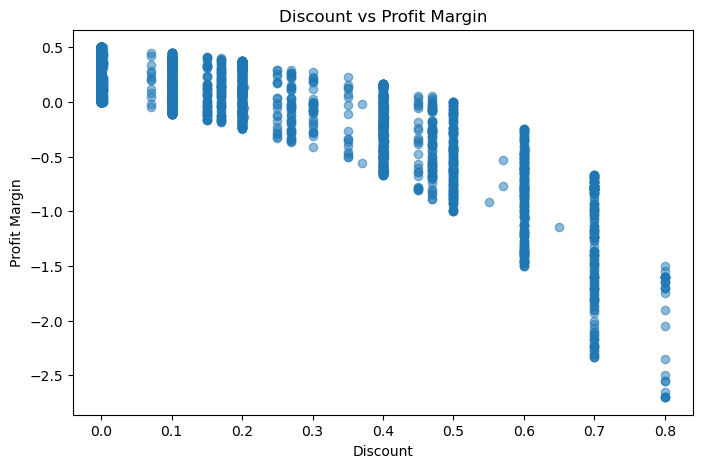

In [25]:
import matplotlib.pyplot as plt

sample = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(sample['Discount'], sample['Profit_Margin'], alpha=0.5)
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin")
plt.show()


This scatter plot shows the relationship between discount and profit margin. The results clearly indicate a strong negative relationship. As discount levels increase, profit margin decreases significantly. At high discount levels (above 0.5), most transactions result in negative profit margins, indicating losses. This confirms that discount is one of the most critical factors affecting profitability in the dataset.


In [26]:
from scipy.stats import kruskal

bands = ["0%","0-10%","10-20%","20-40%","40%+"]

groups = [df[df['Discount_Band']==b]['Profit_Margin'].dropna() for b in bands]

stat, p_value = kruskal(*groups)

print("Test Statistic:", stat)
print("P-value:", p_value)


Test Statistic: 25991.562693947435
P-value: 0.0


A Kruskal-Wallis statistical test was conducted to evaluate whether profit margins differ significantly across discount levels. The test produced a p-value of 0.0, which is far below the significance threshold of 0.05. This result confirms that discount levels have a statistically significant impact on profit margin. Therefore, discount is a critical driver of profitability in the Global Superstore dataset. Higher discount levels are associated with significantly lower profit margins and increased likelihood of losses.


In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = ['Discount','Shipping_Cost','Quantity','Shipping_Days','Sales']
target = 'Profit'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False)


Sales            0.575956
Discount         0.283805
Shipping_Cost    0.072478
Quantity         0.038197
Shipping_Days    0.029564
dtype: float64

A Random Forest regression model was used to identify the most important drivers of profit. The results show that Sales is the strongest predictor of profit, followed by Discount. Discount alone accounts for approximately 28% of the variation in profit, confirming its significant influence. Combined with the Kruskal-Wallis statistical test and scatter plot analysis, this provides strong evidence that discount levels are one of the most critical controllable factors affecting profitability. High discount levels substantially reduce profit and increase the likelihood of losses. Shipping cost also contributes to profit variation, while quantity and shipping days have relatively smaller effects.
